In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
dataset = pd.read_csv("Social_Network_Ads.csv")

In [61]:
dataset.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [44]:
x = dataset.iloc[:,:-1]

In [45]:
y = dataset["Purchased"]

In [46]:
x = (x - x.mean(axis=0)) / x.std(axis=0)

In [47]:
def log_loss(y,y_pred):
    esp = 1e-15
    y_pred = np.clip(y_pred,esp,1-esp)
    return -np.mean(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))

In [48]:
def sigmoid(z):
    z = np.clip(z,-500,500)
    return 1 / (1+np.exp(-z))

In [49]:
t0 = 0
t1 = 0
t2 = 0
lr = 0.001
maxitr = 100000
tolerance = 1e-6
n = len(x)

In [50]:
prev_loss = float("inf")

In [51]:
for i in range(maxitr):
    
    z = (t1*x["Age"]) + (t2*x["EstimatedSalary"]) + t0
    y_pred = sigmoid(z)
    
    dm1 = (1/n) * np.sum((y_pred-y)*x["Age"])
    dm2 = (1/n) * np.sum((y_pred-y)*x["EstimatedSalary"])
    dm0 = (1/n) * np.sum(y_pred-y)

    t1 -= lr * dm1
    t2 -= lr * dm2
    t0 -= lr * dm0

    loss = log_loss(y, y_pred)

    if i % 200 == 0:
        print(f"Epoch {i}, Loss = {loss:.4f}")

    if abs(prev_loss - loss) < tolerance:
        print(f"\nTraining stopped early at epoch {i}")
        break

    prev_loss = loss

Epoch 0, Loss = 0.6931
Epoch 200, Loss = 0.6668
Epoch 400, Loss = 0.6432
Epoch 600, Loss = 0.6221
Epoch 800, Loss = 0.6031
Epoch 1000, Loss = 0.5861
Epoch 1200, Loss = 0.5707
Epoch 1400, Loss = 0.5568
Epoch 1600, Loss = 0.5442
Epoch 1800, Loss = 0.5327
Epoch 2000, Loss = 0.5222
Epoch 2200, Loss = 0.5127
Epoch 2400, Loss = 0.5039
Epoch 2600, Loss = 0.4959
Epoch 2800, Loss = 0.4885
Epoch 3000, Loss = 0.4816
Epoch 3200, Loss = 0.4753
Epoch 3400, Loss = 0.4694
Epoch 3600, Loss = 0.4639
Epoch 3800, Loss = 0.4588
Epoch 4000, Loss = 0.4540
Epoch 4200, Loss = 0.4496
Epoch 4400, Loss = 0.4454
Epoch 4600, Loss = 0.4415
Epoch 4800, Loss = 0.4378
Epoch 5000, Loss = 0.4343
Epoch 5200, Loss = 0.4311
Epoch 5400, Loss = 0.4280
Epoch 5600, Loss = 0.4251
Epoch 5800, Loss = 0.4223
Epoch 6000, Loss = 0.4197
Epoch 6200, Loss = 0.4172
Epoch 6400, Loss = 0.4149
Epoch 6600, Loss = 0.4126
Epoch 6800, Loss = 0.4105
Epoch 7000, Loss = 0.4085
Epoch 7200, Loss = 0.4065
Epoch 7400, Loss = 0.4047
Epoch 7600, Loss = 

In [53]:
# print("\nBest m:", m)
# print("Best b:", b)

In [54]:
print("\nBest parameters:")
print("t0 =", t0)
print("t1 =", t1)
print("t2 =", t2)


Best parameters:
t0 = -0.8519010955186312
t1 = 1.7501272805948336
t2 = 0.8884216584251424


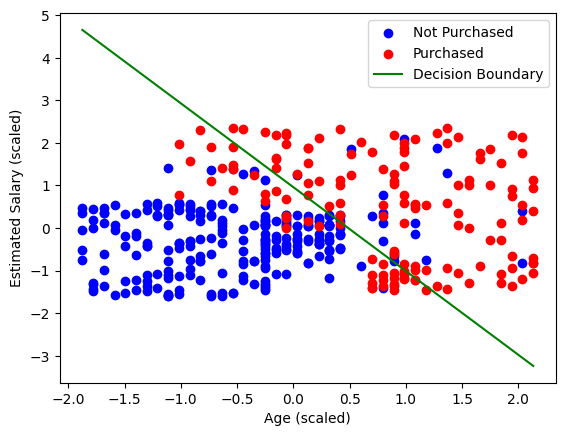

In [62]:
# Convert once
X = x.values
y_np = y.values

plt.scatter(X[y_np==0, 0], X[y_np==0, 1], color="blue", label="Not Purchased")
plt.scatter(X[y_np==1, 0], X[y_np==1, 1], color="red", label="Purchased")

x1_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x2_vals = -(t1*x1_vals + t0) / t2

plt.plot(x1_vals, x2_vals, color="green", label="Decision Boundary")

plt.xlabel("Age (scaled)")
plt.ylabel("Estimated Salary (scaled)")
plt.legend()
plt.show()
